In [2]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
Bike_name = []
Price = []
CC = []
Mileage = []
Weight = []
Rating = []
No_of_Ratings = []

base_url = "https://www.bikewale.com/best-bikes-in-india/?pageNumber={}&pageSize=30"

for page in range(1, 40):   
    url = base_url.format(page)
    response = requests.get(url)

    soup = BeautifulSoup(response.text, "html.parser")

 
    names = soup.find_all("span", class_="o-jJ o-j3 o-js o-ez")
    for n in names:
        Bike_name.append(n.text.strip())

    
    prices = soup.find_all("span", class_="o-jJ o-jr o-j3 o-kJ")
    for p in prices:
        Price.append(p.text.strip())

    specs = soup.find_all("span", class_="o-iZ o-jf")

    cc = []
    mileage = []
    weight = []

    for i in range(0, len(specs), 4):
        cc.append(specs[i].text.strip())

    for i in range(1, len(specs), 4):
        mileage.append(specs[i].text.strip())

    for i in range(3, len(specs), 4):
        weight.append(specs[i].text.strip())

    CC.extend(cc)
    Mileage.extend(mileage)
    Weight.extend(weight)

    ratings = soup.find_all("p", class_="o-j1 o-cx o-jq o-d o-j o-jJ")
    for r in ratings:
        Rating.append(r.text.split("/")[0].strip())


    noratings = soup.find_all("span", class_="o-jL o-f7 o-j0 o-jc o-fE")
    for nr in noratings:
        No_of_Ratings.append(nr.text.split()[0])


min_length = min(len(Bike_name), len(Price), len(CC), len(Mileage), 
                 len(Weight), len(Rating), len(No_of_Ratings))

data = {
    "Bike_name": Bike_name[:min_length],
    "Price": Price[:min_length],
    "CC": CC[:min_length],
    "Mileage": Mileage[:min_length],
    "Weight": Weight[:min_length],
    "Rating": Rating[:min_length],
    "No_of_Ratings": No_of_Ratings[:min_length]
}

df = pd.DataFrame(data)

In [3]:
df

,Bike_name,Price,CC,Mileage,Weight,Rating,No_of_Ratings
0,Bajaj Pulsar N160,"₹ 1,14,840",164.82 cc|,51.6 kmpl|,152 kg,4.6,290
1,Royal Enfield Hunter 350,"₹ 1,37,648",349.34 cc|,36.2 kmpl|,181 kg,4.7,340
2,Royal Enfield Classic 350,"₹ 1,82,667",349 cc|,35 kmpl|,195 kg,4.7,257
3,Royal Enfield Bullet 350,"₹ 1,63,503",349 cc|,35 kmpl|,195 kg,4.7,277
4,Yamaha MT 15 V2,"₹ 1,59,195",155 cc|,47 kmpl|,141 kg,4.7,334
...,...,...,...,...,...,...,...
378,Evolet Derby,"₹ 71,399",3.12 kWh,2.2 kWh,120 km|,5,1
379,Gemopai Ryder,"₹ 70,822",80 km|,1.92 kWh,100 km|,4.5,2
380,Gemopai Astrid Lite,"₹ 92,290",110 kg|,60 kmph|,104 km|,4.8,4
381,Joy e-bike Glob,"₹ 70,000",2.2 kWh,70 kmph|,98 km|,5,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Bike_name      383 non-null    object
 1   Price          383 non-null    object
 2   CC             383 non-null    object
 3   Mileage        383 non-null    object
 4   Weight         383 non-null    object
 5   Rating         383 non-null    object
 6   No_of_Ratings  383 non-null    object
dtypes: object(7)
memory usage: 21.1+ KB


In [5]:
df.describe()

,Bike_name,Price,CC,Mileage,Weight,Rating,No_of_Ratings
count,383,383,383,383,383,383,383
unique,383,378,267,268,292,27,144
top,Bajaj Pulsar N160,"₹ 13,37,500",25 kmph|,35 kmpl|,115 kg,4.6,3
freq,1,2,6,11,6,54,26


In [6]:
df.isnull().sum()

Bike_name        0
Price            0
CC               0
Mileage          0
Weight           0
Rating           0
No_of_Ratings    0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df["Price"] = df["Price"].str.replace(r"[₹,\s]", "",regex=True)
df["Price"]=df["Price"].astype("int64")

In [9]:
df["CC"]=df["CC"].str.replace(r"[cc|kgkmphbhpkmph|kg|Wl/]","",regex=True)
df["CC"]=df["CC"].astype("float")

In [10]:
df["Mileage"]=df["Mileage"].str.replace(r"[kmpl|km/kgkg|bhWhcc]","",regex=True)
df["Mileage"]=df["Mileage"].astype("float")

In [11]:
df["Weight"]=df["Weight"].str.replace(r"[kgkWhccbhpkmplkmkg|]","",regex=True)
df["Weight"]=df["Weight"].astype("float")

In [12]:
df["Rating"] = df["Rating"].astype("float")

In [13]:
df["No_of_Ratings"]=df["No_of_Ratings"].astype(np.int32)

In [14]:
df.isna().sum()

Bike_name        0
Price            0
CC               0
Mileage          0
Weight           0
Rating           0
No_of_Ratings    0
dtype: int64

In [15]:
df.head()

,Bike_name,Price,CC,Mileage,Weight,Rating,No_of_Ratings
0,Bajaj Pulsar N160,114840,164.82,51.6,152.0,4.6,290
1,Royal Enfield Hunter 350,137648,349.34,36.2,181.0,4.7,340
2,Royal Enfield Classic 350,182667,349.00,35.0,195.0,4.7,257
3,Royal Enfield Bullet 350,163503,349.00,35.0,195.0,4.7,277
4,Yamaha MT 15 V2,159195,155.00,47.0,141.0,4.7,334


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Bike_name      383 non-null    object 
 1   Price          383 non-null    int64  
 2   CC             383 non-null    float64
 3   Mileage        383 non-null    float64
 4   Weight         383 non-null    float64
 5   Rating         383 non-null    float64
 6   No_of_Ratings  383 non-null    int32  
dtypes: float64(4), int32(1), int64(1), object(1)
memory usage: 19.6+ KB


In [17]:
df["Brand"] = df["Bike_name"].str.split().str[0]

In [18]:
df["price_category"]= df["Price"].apply(
    lambda x: "low" if x<100000 else "Mid" if 100000 < x < 400000   else "High"
)

In [19]:
df["price_category"].value_counts()

price_category
Mid     182
High    125
low      76
Name: count, dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Bike_name       383 non-null    object 
 1   Price           383 non-null    int64  
 2   CC              383 non-null    float64
 3   Mileage         383 non-null    float64
 4   Weight          383 non-null    float64
 5   Rating          383 non-null    float64
 6   No_of_Ratings   383 non-null    int32  
 7   Brand           383 non-null    object 
 8   price_category  383 non-null    object 
dtypes: float64(4), int32(1), int64(1), object(3)
memory usage: 25.6+ KB


In [21]:
#univariate analysis

Text(0.5, 1.0, 'Rating distrubution')

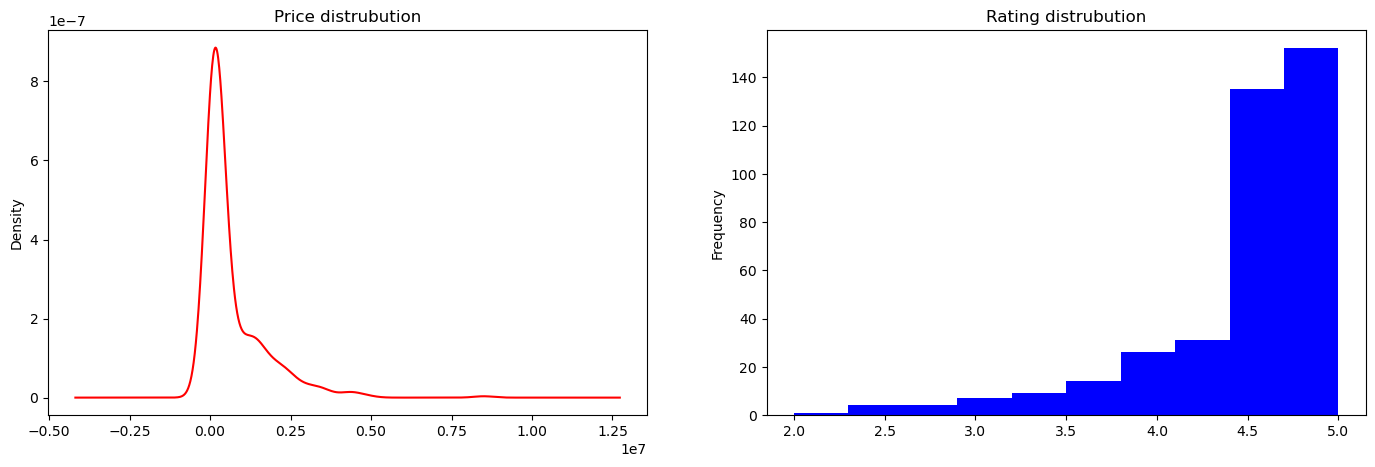

In [31]:
fig, axes = plt.subplots(1,2, figsize=(17,5))
df["Price"].plot(kind="kde",ax=axes[0],color="red")
axes[0].set_title("Price distrubution")
df["Rating"].plot(kind="hist",ax=axes[1],color="blue")
axes[1].set_title("Rating distrubution")

Text(0.5, 1.0, 'No.of ratings distrubution')

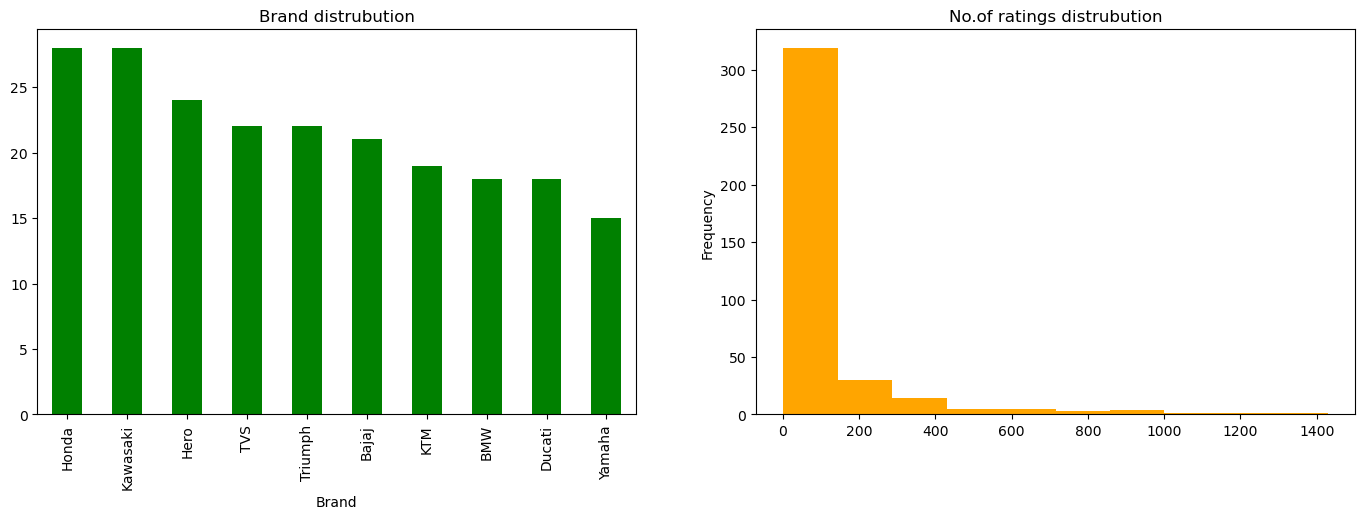

In [34]:
fig, axes = plt.subplots(1,2, figsize=(17,5))
df["Brand"].value_counts().head(10).plot(kind="bar",ax=axes[0],color="green")
axes[0].set_title("Brand distrubution")
df["No_of_Ratings"].plot(kind="hist",ax=axes[1], color="orange")
axes[1].set_title("No.of ratings distrubution")

In [37]:
#Bivariate analysis

In [38]:
#num vs num

<function matplotlib.pyplot.show(close=None, block=None)>

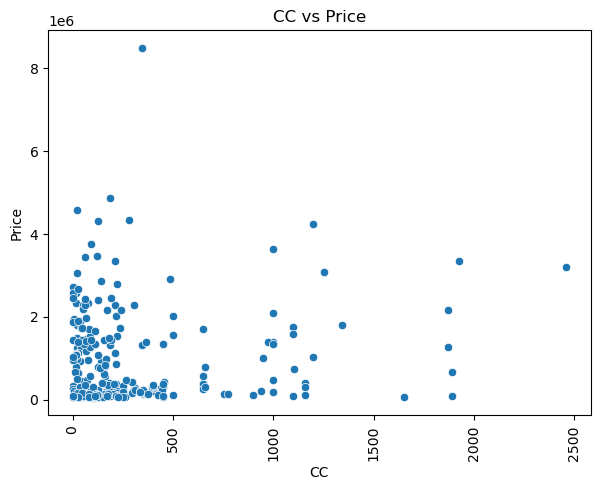

In [39]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["CC"], y=df["Price"])
plt.xticks(rotation=90)
plt.title("CC vs Price")
plt.show

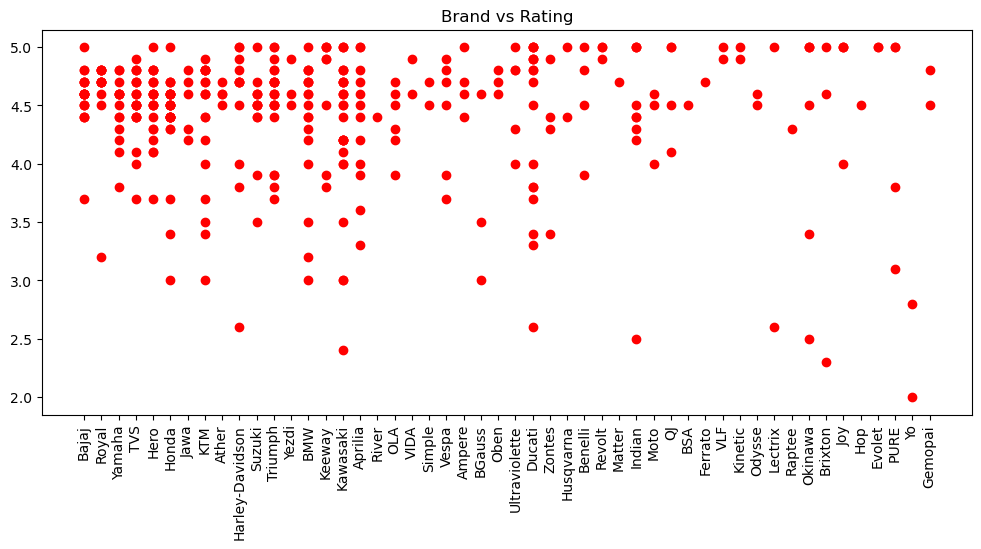

In [40]:
plt.figure(figsize=(12,5))
plt.scatter(df['Brand'],df['Rating'],color='red')
plt.xticks(rotation=90)
plt.title("Brand vs Rating")
plt.show()

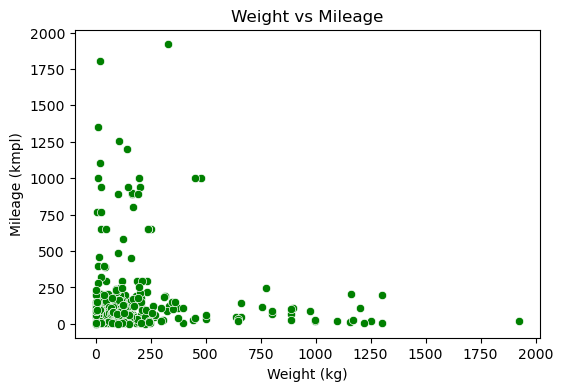

In [41]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Weight", y="Mileage",color='green')
plt.title("Weight vs Mileage")
plt.xlabel("Weight (kg)")
plt.ylabel("Mileage (kmpl)")
plt.show()

In [42]:
#cat vs cat

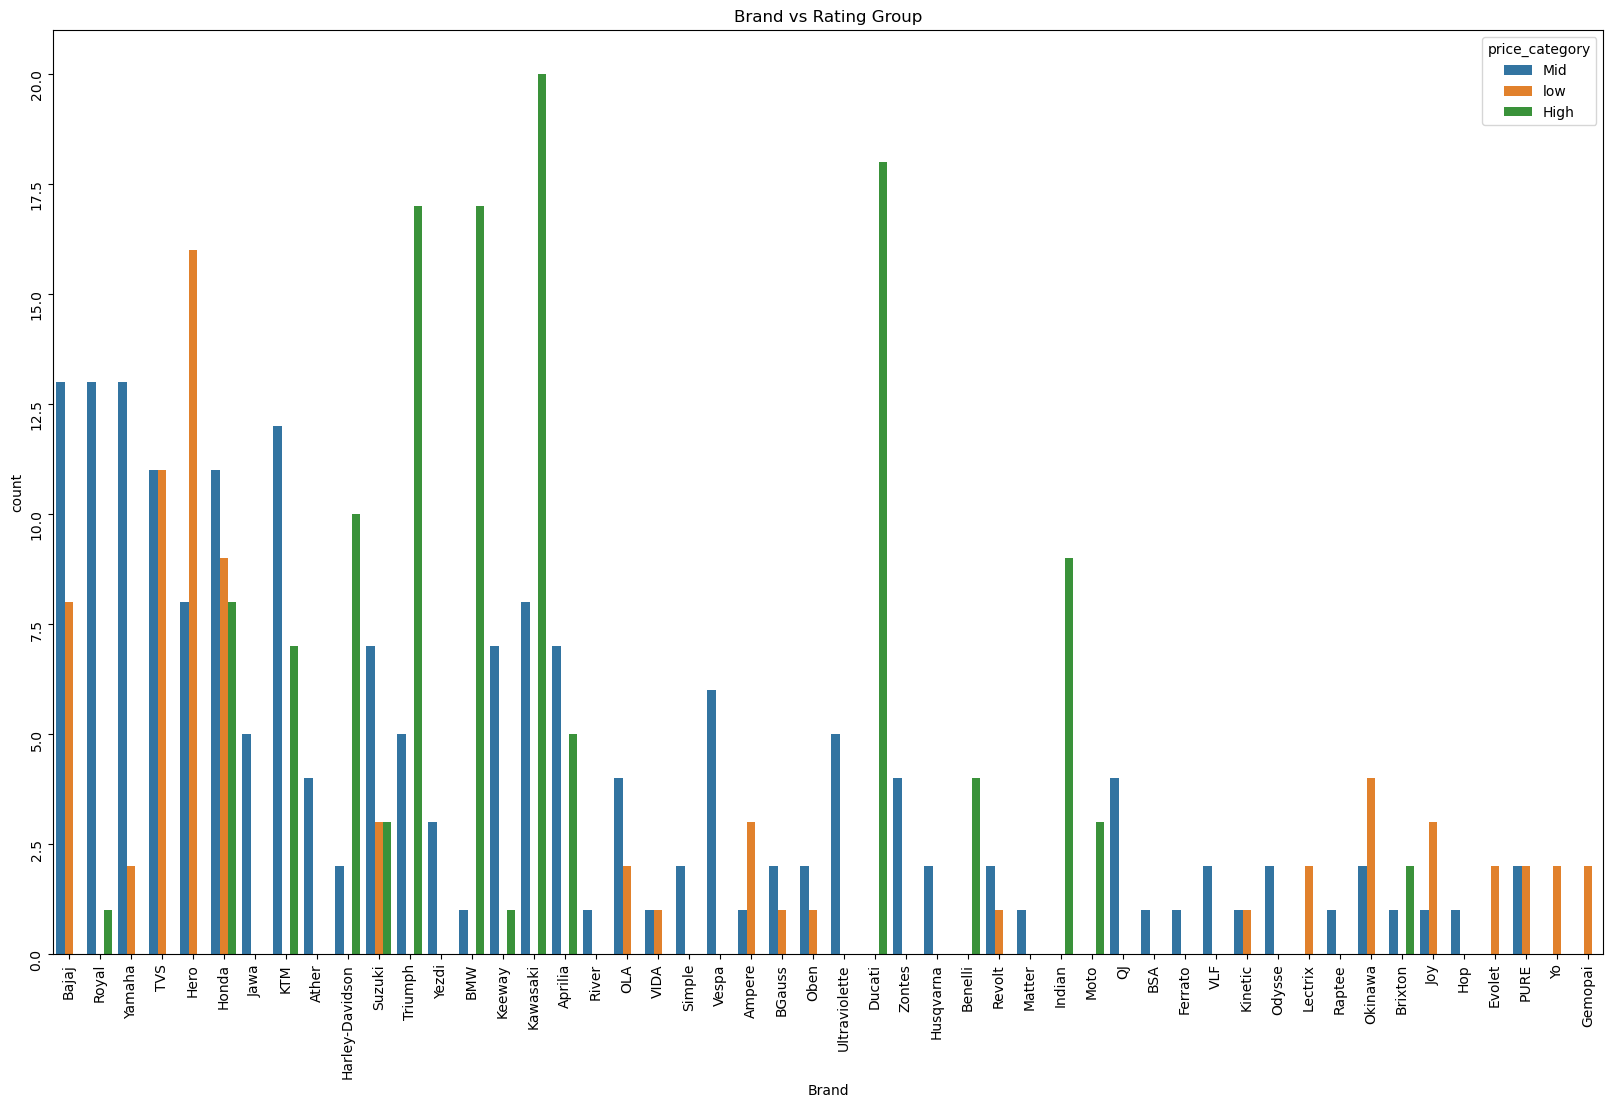

In [43]:
plt.figure(figsize=(20,12))
sns.countplot(data=df,x="Brand",hue="price_category")
plt.xticks(rotation=90)
plt.yticks(rotation=90)
plt.title("Brand vs Rating Group")
plt.show()

In [44]:
#num vs cat

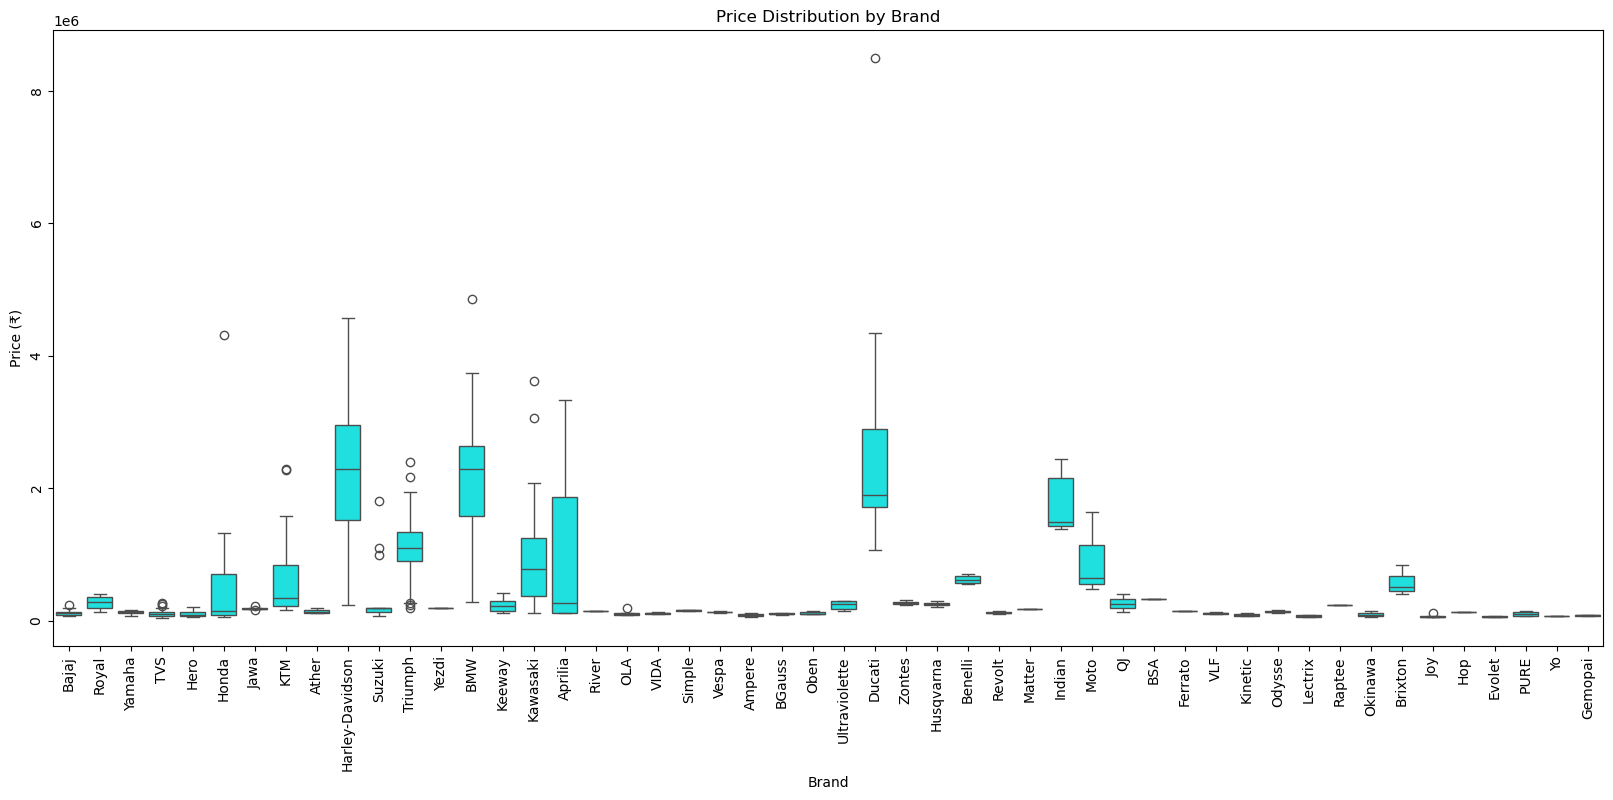

In [45]:
plt.figure(figsize=(20,8))
sns.boxplot(data=df, x="Brand", y="Price",color='cyan')
plt.xticks(rotation=90)
plt.title("Price Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("Price (₹)")
plt.yticks(rotation=90)
plt.show()

In [46]:
#Multi variate analysis

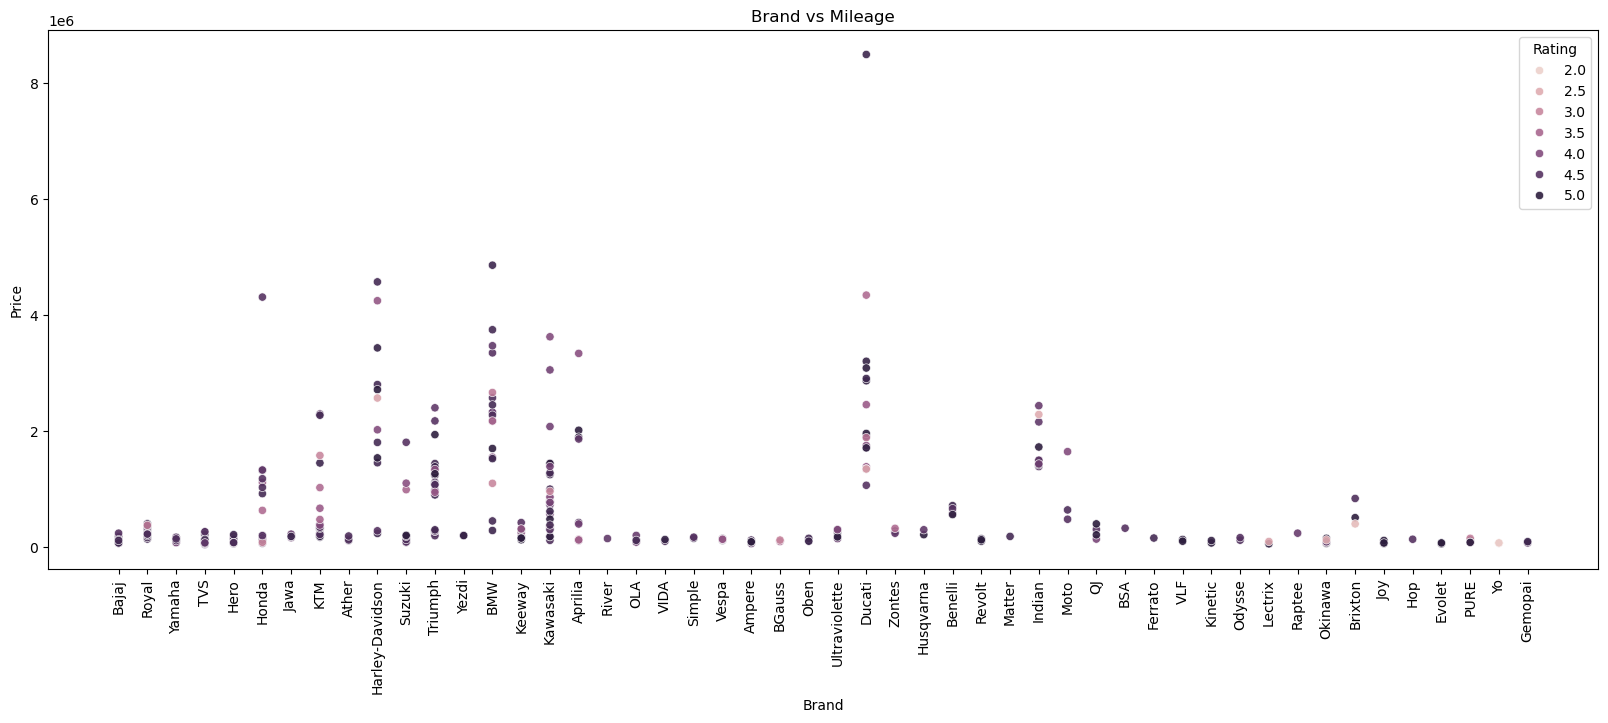

In [48]:
plt.figure(figsize=(20,7))
sns.scatterplot(data=df,x="Brand",y="Price",hue="Rating",alpha=0.9)
plt.title("Brand vs Mileage")
plt.xticks(rotation=90)
plt.show()

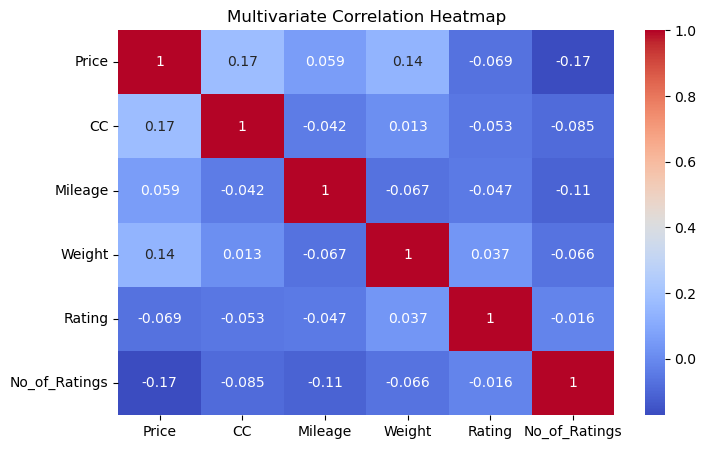

In [49]:
plt.figure(figsize=(8,5))
sns.heatmap(df[["Price", "CC", "Mileage", "Weight", "Rating", "No_of_Ratings"]].corr(), annot=True, cmap="coolwarm")
plt.title("Multivariate Correlation Heatmap")
plt.show()

In [50]:
df.describe()

,Price,CC,Mileage,Weight,Rating,No_of_Ratings
count,3.830000e+02,383.000000,383.000000,383.000000,383.000000,383.000000
mean,6.782488e+05,242.194339,144.751488,187.306877,4.443342,90.232376
std,9.967830e+05,345.377878,250.419836,246.261457,0.528954,187.908970
min,4.375200e+04,1.152000,0.600000,0.600000,2.000000,1.000000
25%,1.145180e+05,60.000000,30.785000,70.000000,4.350000,5.000000
50%,1.953050e+05,125.000000,60.000000,128.200000,4.600000,17.000000
75%,9.661300e+05,245.880000,144.500000,190.500000,4.800000,80.000000
max,8.499000e+06,2458.000000,1923.000000,1923.000000,5.000000,1429.000000
